In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# returns

In [92]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_returns.csv'
df_returns = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_returns.head())

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [93]:
df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])
df_returns['year'] = df_returns['return_date'].dt.year
df_returns['month'] = df_returns['return_date'].dt.month

display(df_returns.head())

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,year,month
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,2012,7
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,2012,7
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,2012,7
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75,2012,7
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76,2012,7


In [94]:
daily_returns = df_returns.groupby(['return_date']).agg(
    total_quantity_return =('return_quantity', 'sum'),
    total_refund_amount =('refund_amount', 'sum')
).reset_index()

display(daily_returns.head())

,return_date,total_quantity_return,total_refund_amount
0,2012-07-11,4,6493.75
1,2012-07-12,1,4834.00
2,2012-07-14,6,52967.00
3,2012-07-15,2,13534.62
4,2012-07-16,4,16170.54


In [95]:
start_date = '2012-07-04'
end_date = '2022-12-31'
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Create a DataFrame from the full date range
full_dates_df = pd.DataFrame({'return_date': full_date_range})

# Merge with daily_returns, filling missing values with 0
returns_summary = pd.merge(
    full_dates_df,
    daily_returns,
    on='return_date',
    how='left'
).fillna(0)

# Ensure columns are of the correct type after filling NaN
returns_summary['total_quantity_return'] = returns_summary['total_quantity_return'].astype(int)
returns_summary['total_refund_amount'] = returns_summary['total_refund_amount'].astype(float)

display(returns_summary.head())

,return_date,total_quantity_return,total_refund_amount
0,2012-07-04,0,0.0
1,2012-07-05,0,0.0
2,2012-07-06,0,0.0
3,2012-07-07,0,0.0
4,2012-07-08,0,0.0


In [96]:
display(returns_summary.tail())

,return_date,total_quantity_return,total_refund_amount
3828,2022-12-27,5,26482.11
3829,2022-12-28,19,97387.35
3830,2022-12-29,7,20897.84
3831,2022-12-30,16,43613.12
3832,2022-12-31,15,97557.23


In [97]:
returns_summary.shape

(3833, 3)

In [98]:
# Check for duplicate dates
duplicate_dates = returns_summary[returns_summary.duplicated(subset=['return_date'])]

if not duplicate_dates.empty:
    print(f"Found {len(duplicate_dates)} duplicate dates:")
    display(duplicate_dates)
else:
    print("No duplicate dates found in 'returns_summary'.")

No duplicate dates found in 'returns_summary'.


In [99]:
returns_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   return_date            3833 non-null   datetime64[ns]
 1   total_quantity_return  3833 non-null   int64         
 2   total_refund_amount    3833 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 90.0 KB


# orders

In [13]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_orders.csv'
df_orders = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_orders.head())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [14]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


In [15]:
# Convert 'order_date' to datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Drop the 'zip' column
df_orders_processed = df_orders.drop(columns=['zip'])

display(df_orders_processed.head())

,order_id,order_date,customer_id,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,delivered,paypal,mobile,email_campaign


In [16]:
# Identify object columns for one-hot encoding
categorical_cols = df_orders_processed.select_dtypes(include='object').columns

df_orders_encoded = pd.get_dummies(
    df_orders_processed,
    columns=categorical_cols,
    drop_first=False
)

# Convert only the columns that should be integers (dummified columns and original int columns)
# while ensuring 'order_date' remains datetime.
for col in df_orders_encoded.columns:
    if col != 'order_date':
        if df_orders_encoded[col].dtype in ['uint8', 'bool'] or 'int' in str(df_orders_encoded[col].dtype):
            df_orders_encoded[col] = df_orders_encoded[col].astype(int)

display(df_orders_encoded.head())

,order_id,order_date,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,payment_method_paypal,device_type_desktop,device_type_mobile,device_type_tablet,order_source_direct,order_source_email_campaign,order_source_organic_search,order_source_paid_search,order_source_referral,order_source_social_media
0,1,2012-07-04,58578,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,2,2012-07-04,58621,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
2,3,2012-07-04,58811,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
3,4,2012-07-04,59453,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4,6,2012-07-06,57821,0,0,1,0,0,0,0,...,1,0,1,0,0,1,0,0,0,0


In [17]:
# Group by 'order_date' and aggregate
# We will count unique order_id and customer_id
# For one-hot encoded columns, we sum them to get daily counts of each category

# Prepare aggregation dictionary
agg_dict = {
    'order_id': pd.Series.nunique, # Count unique order_ids
    'customer_id': pd.Series.nunique # Count unique customer_ids
}

# Add one-hot encoded columns to the aggregation dictionary with 'sum'
for col in df_orders_encoded.columns:
    if col not in ['order_date', 'order_id', 'customer_id']:
        agg_dict[col] = 'sum'

orders_summary = df_orders_encoded.groupby('order_date').agg(agg_dict).reset_index()

display(orders_summary.head())

,order_date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,payment_method_paypal,device_type_desktop,device_type_mobile,device_type_tablet,order_source_direct,order_source_email_campaign,order_source_organic_search,order_source_paid_search,order_source_referral,order_source_social_media
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,31,67,69,26,9,14,52,30,16,41
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,18,43,38,16,6,11,26,18,9,27
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,13,42,42,9,10,12,28,23,7,13
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,8,26,34,13,2,13,20,15,12,11
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,13,30,45,13,7,11,22,18,2,28


In [18]:
orders_summary.shape

(3833, 23)

In [19]:
orders_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   order_date                    3833 non-null   datetime64[ns]
 1   order_id                      3833 non-null   int64         
 2   customer_id                   3833 non-null   int64         
 3   order_status_cancelled        3833 non-null   int64         
 4   order_status_created          3833 non-null   int64         
 5   order_status_delivered        3833 non-null   int64         
 6   order_status_paid             3833 non-null   int64         
 7   order_status_returned         3833 non-null   int64         
 8   order_status_shipped          3833 non-null   int64         
 9   payment_method_apple_pay      3833 non-null   int64         
 10  payment_method_bank_transfer  3833 non-null   int64         
 11  payment_method_cod            

# shipments

In [20]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_shipments.csv'
df_shipments = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_shipments.head())

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [21]:
# Convert date columns to datetime
df_shipments['ship_date'] = pd.to_datetime(df_shipments['ship_date'])
df_shipments['delivery_date'] = pd.to_datetime(df_shipments['delivery_date'])

display(df_shipments.head())

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [22]:
# Aggregate daily shipped orders and total shipping fees
daily_shipped_summary = df_shipments.groupby('ship_date').agg(
    shipped_orders_count=('order_id', 'count'),
    total_shipping_fee=('shipping_fee', 'sum')
).reset_index()

# Rename 'ship_date' to 'date' for merging
daily_shipped_summary = daily_shipped_summary.rename(columns={'ship_date': 'date'})

display(daily_shipped_summary.head())

,date,shipped_orders_count,total_shipping_fee
0,2012-07-04,33,157.76
1,2012-07-05,45,172.75
2,2012-07-06,94,292.15
3,2012-07-07,92,328.58
4,2012-07-08,78,428.18


In [23]:
# Aggregate daily delivered orders
daily_delivered_summary = df_shipments.groupby('delivery_date').agg(
    delivered_orders_count=('order_id', 'count')
).reset_index()

# Rename 'delivery_date' to 'date' for merging
daily_delivered_summary = daily_delivered_summary.rename(columns={'delivery_date': 'date'})

display(daily_delivered_summary.head())

,date,delivered_orders_count
0,2012-07-06,6
1,2012-07-07,15
2,2012-07-08,31
3,2012-07-09,49
4,2012-07-10,43


**Merge with Full Date Range**

Now, I'll create a full date range and merge the daily shipment and delivery summaries to ensure all days from '2012-07-04' to '2022-12-31' are included, filling missing values with 0.

In [24]:
# Use the same full date range as for returns and orders
start_date_shipments = '2012-07-04'
end_date_shipments = '2022-12-31'
full_date_range_shipments = pd.DataFrame({'date': pd.date_range(start=start_date_shipments, end=end_date_shipments, freq='D')})

# Merge shipped and delivered summaries with the full date range
shipments_summary = pd.merge(
    full_date_range_shipments,
    daily_shipped_summary,
    on='date',
    how='left'
).fillna(0)

shipments_summary = pd.merge(
    shipments_summary,
    daily_delivered_summary,
    on='date',
    how='left'
).fillna(0)

# Ensure columns are of the correct type after filling NaN
shipments_summary['shipped_orders_count'] = shipments_summary['shipped_orders_count'].astype(int)
shipments_summary['delivered_orders_count'] = shipments_summary['delivered_orders_count'].astype(int)
shipments_summary['total_shipping_fee'] = shipments_summary['total_shipping_fee'].astype(float)

display(shipments_summary.head())

,date,shipped_orders_count,total_shipping_fee,delivered_orders_count
0,2012-07-04,33,157.76,0
1,2012-07-05,45,172.75,0
2,2012-07-06,94,292.15,6
3,2012-07-07,92,328.58,15
4,2012-07-08,78,428.18,31


In [25]:
display(shipments_summary.tail())

,date,shipped_orders_count,total_shipping_fee,delivered_orders_count
3828,2022-12-27,44,256.63,83
3829,2022-12-28,30,202.67,75
3830,2022-12-29,20,211.90,72
3831,2022-12-30,0,0.00,76
3832,2022-12-31,0,0.00,77


In [26]:
shipments_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    3833 non-null   datetime64[ns]
 1   shipped_orders_count    3833 non-null   int64         
 2   total_shipping_fee      3833 non-null   float64       
 3   delivered_orders_count  3833 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 119.9 KB


In [27]:
shipments_summary.shape

(3833, 4)

# payments

In [28]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_payments.csv'
df_payments = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_payments.head())

,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [29]:
# Merge df_orders_processed and df_payments on 'order_id'
df_orders_payments = pd.merge(
    df_orders_processed,
    df_payments,
    on='order_id',
    how='left' # Use a left merge to keep all orders and add payment info where available
)

display(df_orders_payments.head())

,order_id,order_date,customer_id,order_status,payment_method_x,device_type,order_source,payment_method_y,payment_value,installments
0,1,2012-07-04,58578,delivered,credit_card,desktop,paid_search,credit_card,7967.54,3
1,2,2012-07-04,58621,returned,cod,mobile,paid_search,cod,71163.75,1
2,3,2012-07-04,58811,delivered,credit_card,desktop,direct,credit_card,33660.99,3
3,4,2012-07-04,59453,delivered,credit_card,desktop,referral,credit_card,53196.25,3
4,6,2012-07-06,57821,delivered,paypal,mobile,email_campaign,paypal,1597.84,1


In [30]:
df_orders_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          646945 non-null  int64         
 1   order_date        646945 non-null  datetime64[ns]
 2   customer_id       646945 non-null  int64         
 3   order_status      646945 non-null  object        
 4   payment_method_x  646945 non-null  object        
 5   device_type       646945 non-null  object        
 6   order_source      646945 non-null  object        
 7   payment_method_y  646945 non-null  object        
 8   payment_value     646945 non-null  float64       
 9   installments      646945 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 49.4+ MB


In [31]:
# Check if 'payment_method_x' and 'payment_method_y' columns are consistent
payment_method_mismatches = df_orders_payments[
    df_orders_payments['payment_method_x'] != df_orders_payments['payment_method_y']
]

if not payment_method_mismatches.empty:
    print(f"Found {len(payment_method_mismatches)} rows where 'payment_method_x' and 'payment_method_y' do not match:")
    display(payment_method_mismatches[['order_id', 'payment_method_x', 'payment_method_y']].head())
else:
    print(" 'payment_method_x' and 'payment_method_y' columns are consistent.")

 'payment_method_x' and 'payment_method_y' columns are consistent.


In [32]:
# Drop 'payment_method_y' as it is consistent with 'payment_method_x'
df_orders_payments = df_orders_payments.drop(columns=['payment_method_y'])

# Rename 'payment_method_x' to 'payment_method'
df_orders_payments = df_orders_payments.rename(columns={'payment_method_x': 'payment_method'})

In [33]:
display(df_orders_payments.head())

,order_id,order_date,customer_id,order_status,payment_method,device_type,order_source,payment_value,installments
0,1,2012-07-04,58578,delivered,credit_card,desktop,paid_search,7967.54,3
1,2,2012-07-04,58621,returned,cod,mobile,paid_search,71163.75,1
2,3,2012-07-04,58811,delivered,credit_card,desktop,direct,33660.99,3
3,4,2012-07-04,59453,delivered,credit_card,desktop,referral,53196.25,3
4,6,2012-07-06,57821,delivered,paypal,mobile,email_campaign,1597.84,1


In [34]:
df_orders_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   order_status    646945 non-null  object        
 4   payment_method  646945 non-null  object        
 5   device_type     646945 non-null  object        
 6   order_source    646945 non-null  object        
 7   payment_value   646945 non-null  float64       
 8   installments    646945 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 44.4+ MB


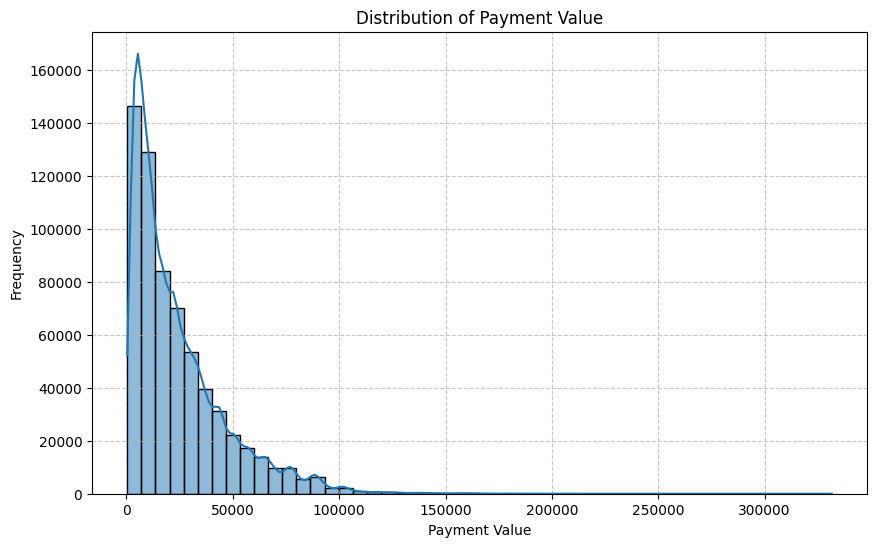

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_orders_payments['payment_value'], bins=50, kde=True)
plt.title('Distribution of Payment Value')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [36]:
# Calculate Q1, Q3, and IQR for 'payment_value'
Q1 = df_orders_payments['payment_value'].quantile(0.25)
Q3 = df_orders_payments['payment_value'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_orders_payments[(df_orders_payments['payment_value'] < lower_bound) | (df_orders_payments['payment_value'] > upper_bound)]

print(f"Number of outliers in 'payment_value': {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

if not outliers.empty:
    print("\nFirst 5 outliers (if any):")
    display(outliers.head())

Number of outliers in 'payment_value': 30219
Lower bound: -31356.87
Upper bound: 72744.29

First 5 outliers (if any):


,order_id,order_date,customer_id,order_status,payment_method,device_type,order_source,payment_value,installments
26,33,2012-07-04,6121,delivered,apple_pay,desktop,referral,74736.48,1
36,45,2012-07-04,66149,delivered,credit_card,mobile,social_media,79082.08,3
43,53,2012-07-06,50806,delivered,apple_pay,desktop,paid_search,80787.84,1
59,76,2012-07-05,52862,delivered,apple_pay,mobile,social_media,88121.32,3
71,89,2012-07-04,27823,delivered,paypal,mobile,email_campaign,73612.35,1


In [37]:
# One-hot encode the 'payment_method' column
df_payments_encoded = pd.get_dummies(df_orders_payments, columns=['payment_method'], drop_first=False)

# Convert boolean columns to integer (0 or 1)
for col in df_payments_encoded.columns:
    if df_payments_encoded[col].dtype == 'bool':
        df_payments_encoded[col] = df_payments_encoded[col].astype(int)

# Prepare aggregation dictionary for daily payments summary
payments_agg_dict = {
    'payment_value': 'mean',
    'installments': 'mean'
}

# Add one-hot encoded payment method columns to the aggregation dictionary with 'sum'
for col in df_payments_encoded.columns:
    if col.startswith('payment_method_'):
        payments_agg_dict[col] = 'sum'

# Group by 'order_date' and aggregate
payments_summary = df_payments_encoded.groupby('order_date').agg(payments_agg_dict).reset_index()

display(payments_summary.head())

,order_date,payment_value,installments,payment_method_apple_pay,payment_method_bank_transfer,payment_method_cod,payment_method_credit_card,payment_method_paypal
0,2012-07-04,31626.839136,3.790123,19,5,22,85,31
1,2012-07-05,28368.798454,3.917526,7,9,16,47,18
2,2012-07-06,32839.026022,4.139785,8,1,11,60,13
3,2012-07-07,36546.999178,2.904110,10,1,14,40,8
4,2012-07-08,26827.862500,3.465909,12,5,8,50,13


In [38]:
payments_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   order_date                    3833 non-null   datetime64[ns]
 1   payment_value                 3833 non-null   float64       
 2   installments                  3833 non-null   float64       
 3   payment_method_apple_pay      3833 non-null   int64         
 4   payment_method_bank_transfer  3833 non-null   int64         
 5   payment_method_cod            3833 non-null   int64         
 6   payment_method_credit_card    3833 non-null   int64         
 7   payment_method_paypal         3833 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 239.7 KB


In [39]:
payments_summary.shape

(3833, 8)

# order_items

In [104]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_order_items.csv'
df_order_items = pd.read_csv(file_path)

# Create a flag for promo_id presence
df_order_items['has_promo_id'] = df_order_items['promo_id'].notna().astype(int)

order_items_summary = df_order_items.groupby('order_id').agg(
    total_quantity_order_items=('quantity', 'sum'),
    unique_products_count=('product_id', 'nunique'),
    avg_discount_amount=('discount_amount', 'mean'),
    has_promo_id=('has_promo_id', 'max') # Use max to get 1 if any item in the order had a promo_id
).reset_index()

display(order_items_summary.head())

,order_id,total_quantity_order_items,unique_products_count,avg_discount_amount,has_promo_id
0,1,7,1,0.0,0
1,2,7,1,0.0,0
2,3,3,1,0.0,0
3,4,5,1,0.0,0
4,6,1,1,0.0,0


In [105]:
order_items_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 5 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    646945 non-null  int64  
 1   total_quantity_order_items  646945 non-null  int64  
 2   unique_products_count       646945 non-null  int64  
 3   avg_discount_amount         646945 non-null  float64
 4   has_promo_id                646945 non-null  int64  
dtypes: float64(1), int64(4)
memory usage: 24.7 MB


In [106]:
df_orders_items_payments = pd.merge(
    df_orders_payments,
    order_items_summary,
    on='order_id',
    how='left'
)

display(df_orders_items_payments.head())

,order_id,order_date,customer_id,order_status,payment_method,device_type,order_source,payment_value,installments,total_quantity_order_items,unique_products_count,avg_discount_amount,has_promo_id
0,1,2012-07-04,58578,delivered,credit_card,desktop,paid_search,7967.54,3,7,1,0.0,0
1,2,2012-07-04,58621,returned,cod,mobile,paid_search,71163.75,1,7,1,0.0,0
2,3,2012-07-04,58811,delivered,credit_card,desktop,direct,33660.99,3,3,1,0.0,0
3,4,2012-07-04,59453,delivered,credit_card,desktop,referral,53196.25,3,5,1,0.0,0
4,6,2012-07-06,57821,delivered,paypal,mobile,email_campaign,1597.84,1,1,1,0.0,0


In [107]:
df_orders_items_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   order_id                    646945 non-null  int64         
 1   order_date                  646945 non-null  datetime64[ns]
 2   customer_id                 646945 non-null  int64         
 3   order_status                646945 non-null  object        
 4   payment_method              646945 non-null  object        
 5   device_type                 646945 non-null  object        
 6   order_source                646945 non-null  object        
 7   payment_value               646945 non-null  float64       
 8   installments                646945 non-null  int64         
 9   total_quantity_order_items  646945 non-null  int64         
 10  unique_products_count       646945 non-null  int64         
 11  avg_discount_amount         646945 non-

In [108]:
# Rename date columns for consistent merging
orders_summary_renamed = orders_summary.rename(columns={'order_date': 'date'})
payments_summary_renamed = payments_summary.rename(columns={'order_date': 'date'})
returns_summary_renamed = returns_summary.rename(columns={'return_date': 'date'})

# Merge all daily summaries
daily_transaction_df = pd.merge(orders_summary_renamed, payments_summary_renamed, on='date', how='outer')
daily_transaction_df = pd.merge(daily_transaction_df, returns_summary_renamed, on='date', how='outer')
daily_transaction_df = pd.merge(daily_transaction_df, shipments_summary, on='date', how='outer')

# Fill any remaining NaNs after outer merge with 0, as they represent days with no activity in that specific category
daily_transaction_df = daily_transaction_df.fillna(0)

display(daily_transaction_df.head())
display(daily_transaction_df.tail())

,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay_x,...,payment_method_apple_pay_y,payment_method_bank_transfer_y,payment_method_cod_y,payment_method_credit_card_y,payment_method_paypal_y,total_quantity_return,total_refund_amount,shipped_orders_count,total_shipping_fee,delivered_orders_count
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,19,5,22,85,31,0,0.0,33,157.76,0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,7,9,16,47,18,0,0.0,45,172.75,0
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,8,1,11,60,13,0,0.0,94,292.15,6
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,10,1,14,40,8,0,0.0,92,328.58,15
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,12,5,8,50,13,0,0.0,78,428.18,31


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay_x,...,payment_method_apple_pay_y,payment_method_bank_transfer_y,payment_method_cod_y,payment_method_credit_card_y,payment_method_paypal_y,total_quantity_return,total_refund_amount,shipped_orders_count,total_shipping_fee,delivered_orders_count
3828,2022-12-27,108,107,11,1,86,2,6,2,18,...,18,6,15,55,14,5,26482.11,44,256.63,83
3829,2022-12-28,164,163,20,3,125,8,4,4,18,...,18,10,24,86,26,19,97387.35,30,202.67,75
3830,2022-12-29,143,143,17,4,109,3,7,3,17,...,17,5,18,77,26,7,20897.84,20,211.90,72
3831,2022-12-30,106,106,9,0,85,4,8,0,13,...,13,4,17,57,15,16,43613.12,0,0.00,76
3832,2022-12-31,74,74,2,3,67,1,1,0,2,...,2,3,12,47,10,15,97557.23,0,0.00,77


In [109]:
daily_transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            3833 non-null   datetime64[ns]
 1   order_id                        3833 non-null   int64         
 2   customer_id                     3833 non-null   int64         
 3   order_status_cancelled          3833 non-null   int64         
 4   order_status_created            3833 non-null   int64         
 5   order_status_delivered          3833 non-null   int64         
 6   order_status_paid               3833 non-null   int64         
 7   order_status_returned           3833 non-null   int64         
 8   order_status_shipped            3833 non-null   int64         
 9   payment_method_apple_pay_x      3833 non-null   int64         
 10  payment_method_bank_transfer_x  3833 non-null   int64         
 11  paym

In [110]:
daily_transaction_df.shape

(3833, 35)

In [111]:
# Identify and drop duplicate payment method columns (keeping only _x version which came from orders_summary)
duplicate_payment_cols_to_drop = [
    'payment_method_apple_pay_y',
    'payment_method_bank_transfer_y',
    'payment_method_cod_y',
    'payment_method_credit_card_y',
    'payment_method_paypal_y'
]

daily_transaction_df = daily_transaction_df.drop(columns=duplicate_payment_cols_to_drop)

# Rename the remaining payment method columns by removing the _x suffix
rename_dict = {
    'payment_method_apple_pay_x': 'payment_method_apple_pay',
    'payment_method_bank_transfer_x': 'payment_method_bank_transfer',
    'payment_method_cod_x': 'payment_method_cod',
    'payment_method_credit_card_x': 'payment_method_credit_card',
    'payment_method_paypal_x': 'payment_method_paypal'
}

daily_transaction_df = daily_transaction_df.rename(columns=rename_dict)

print("Columns after dropping duplicates and renaming:")
display(daily_transaction_df.head())
daily_transaction_df.info()

Columns after dropping duplicates and renaming:


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,order_source_paid_search,order_source_referral,order_source_social_media,payment_value,installments,total_quantity_return,total_refund_amount,shipped_orders_count,total_shipping_fee,delivered_orders_count
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,30,16,41,31626.839136,3.790123,0,0.0,33,157.76,0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,18,9,27,28368.798454,3.917526,0,0.0,45,172.75,0
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,23,7,13,32839.026022,4.139785,0,0.0,94,292.15,6
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,15,12,11,36546.999178,2.904110,0,0.0,92,328.58,15
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,18,2,28,26827.862500,3.465909,0,0.0,78,428.18,31


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3833 non-null   datetime64[ns]
 1   order_id                      3833 non-null   int64         
 2   customer_id                   3833 non-null   int64         
 3   order_status_cancelled        3833 non-null   int64         
 4   order_status_created          3833 non-null   int64         
 5   order_status_delivered        3833 non-null   int64         
 6   order_status_paid             3833 non-null   int64         
 7   order_status_returned         3833 non-null   int64         
 8   order_status_shipped          3833 non-null   int64         
 9   payment_method_apple_pay      3833 non-null   int64         
 10  payment_method_bank_transfer  3833 non-null   int64         
 11  payment_method_cod            

# reviews

In [112]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_reviews.csv'
df_reviews = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_reviews.head())

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [113]:
df_reviews.shape

(113551, 7)

In [114]:
# Convert 'review_date' to datetime
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

display(df_reviews.head())

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [115]:
# Bỏ cột review_id
df_reviews = df_reviews.drop(columns=['review_id'])

display(df_reviews.head())

,order_id,product_id,customer_id,review_date,rating,review_title
0,1,2400,58578,2012-07-24,5,Highly recommend
1,3,396,58811,2012-08-03,5,Very satisfied
2,10,1431,49101,2012-07-23,5,Great quality
3,16,1668,41028,2012-08-05,5,Great quality
4,17,2352,42030,2012-07-17,4,Good overall


In [116]:
print(df_reviews.info())
print('\nCardinality of object columns before one-hot encoding:')
for col in df_reviews.select_dtypes(include='object').columns:
    print(f"- '{col}': {df_reviews[col].nunique()} unique values")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      113551 non-null  int64         
 1   product_id    113551 non-null  int64         
 2   customer_id   113551 non-null  int64         
 3   review_date   113551 non-null  datetime64[ns]
 4   rating        113551 non-null  int64         
 5   review_title  113551 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 5.2+ MB
None

Cardinality of object columns before one-hot encoding:
- 'review_title': 18 unique values


As you can see, `review_text` has a very high number of unique values, making it unsuitable for direct one-hot encoding. The `title` column might also have high cardinality, but it is typically more structured than free text. I will proceed with one-hot encoding only the `title` column, as indicated by your subsequent aggregation on `title_` prefixed columns.

In [117]:
# Identify object columns for one-hot encoding, explicitly excluding 'review_text'
categorical_cols_reviews = [col for col in df_reviews.select_dtypes(include='object').columns if col != 'review_text']

df_reviews_encoded = pd.get_dummies(
    df_reviews,
    columns=categorical_cols_reviews,
    drop_first=False
)

# Convert boolean columns to integer (0 or 1)
for col in df_reviews_encoded.columns:
    if df_reviews_encoded[col].dtype == 'bool':
        df_reviews_encoded[col] = df_reviews_encoded[col].astype(int)

display(df_reviews_encoded.head())

,order_id,product_id,customer_id,review_date,rating,review_title_Average product,review_title_Below expectations,"review_title_Decent, nothing special",review_title_Excellent product!,review_title_Good overall,...,review_title_Mixed feelings,review_title_Not as described,review_title_Poor quality,review_title_Solid choice,review_title_Some issues,review_title_Very disappointed,review_title_Very satisfied,review_title_Works well,review_title_Would not recommend,review_title_Would not reorder
0,1,2400,58578,2012-07-24,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,396,58811,2012-08-03,5,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,10,1431,49101,2012-07-23,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,16,1668,41028,2012-08-05,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,17,2352,42030,2012-07-17,4,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [118]:
reviews_agg_dict = {
    'order_id': pd.Series.nunique, # Total number of orders reviewed
    'customer_id': pd.Series.nunique, # Total unique customers who reviewed
    'product_id': pd.Series.nunique, # Total unique products reviewed
    'rating': 'mean' # Average rating
}

# Add one-hot encoded 'title' columns to the aggregation dictionary with 'sum'
for col in df_reviews_encoded.columns:
    if col.startswith('review_title_'):
        reviews_agg_dict[col] = 'sum'

# Group by 'review_date' and aggregate
reviews_summary = df_reviews_encoded.groupby('review_date').agg(reviews_agg_dict).reset_index()

# Rename columns with '_reviews' suffix
reviews_summary = reviews_summary.rename(columns={
    'order_id': 'order_id_reviews',
    'customer_id': 'customer_id_reviews',
    'product_id': 'product_id_reviews'
})

display(reviews_summary.head())

,review_date,order_id_reviews,customer_id_reviews,product_id_reviews,rating,review_title_Average product,review_title_Below expectations,"review_title_Decent, nothing special",review_title_Excellent product!,review_title_Good overall,...,review_title_Mixed feelings,review_title_Not as described,review_title_Poor quality,review_title_Solid choice,review_title_Some issues,review_title_Very disappointed,review_title_Very satisfied,review_title_Works well,review_title_Would not recommend,review_title_Would not reorder
0,2012-07-10,1,1,1,5.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2012-07-12,1,1,1,5.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2012-07-13,2,2,2,4.50,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
3,2012-07-14,2,2,2,3.50,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2012-07-15,4,4,4,4.25,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [119]:
reviews_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3825 entries, 0 to 3824
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   review_date                           3825 non-null   datetime64[ns]
 1   order_id_reviews                      3825 non-null   int64         
 2   customer_id_reviews                   3825 non-null   int64         
 3   product_id_reviews                    3825 non-null   int64         
 4   rating                                3825 non-null   float64       
 5   review_title_Average product          3825 non-null   int64         
 6   review_title_Below expectations       3825 non-null   int64         
 7   review_title_Decent, nothing special  3825 non-null   int64         
 8   review_title_Excellent product!       3825 non-null   int64         
 9   review_title_Good overall             3825 non-null   int64         
 10  

In [120]:
reviews_summary.shape

(3825, 23)

Now, I will create a full date range and merge the daily reviews summary to ensure all days from '2012-07-04' to '2022-12-31' are included, filling missing values with 0.

In [121]:
# Use the specified full date range
start_date_reviews = '2012-07-04'
end_date_reviews = '2022-12-31'
full_date_range_reviews = pd.DataFrame({'review_date': pd.date_range(start=start_date_reviews, end=end_date_reviews, freq='D')})

# Merge with daily_reviews, filling missing values with 0
full_reviews_summary = pd.merge(
    full_date_range_reviews,
    reviews_summary,
    on='review_date',
    how='left'
).fillna(0)

# Ensure columns are of the correct type after filling NaN where appropriate
# Convert to int only if the column is not 'rating' (which is float)
for col in ['order_id', 'customer_id', 'product_id']:
    if col in full_reviews_summary.columns:
        full_reviews_summary[col] = full_reviews_summary[col].astype(int)

# For one-hot encoded title columns, convert to int
for col in full_reviews_summary.columns:
    if col.startswith('title_'):
        full_reviews_summary[col] = full_reviews_summary[col].astype(int)

display(full_reviews_summary.head())
display(full_reviews_summary.tail())

,review_date,order_id_reviews,customer_id_reviews,product_id_reviews,rating,review_title_Average product,review_title_Below expectations,"review_title_Decent, nothing special",review_title_Excellent product!,review_title_Good overall,...,review_title_Mixed feelings,review_title_Not as described,review_title_Poor quality,review_title_Solid choice,review_title_Some issues,review_title_Very disappointed,review_title_Very satisfied,review_title_Works well,review_title_Would not recommend,review_title_Would not reorder
0,2012-07-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,review_date,order_id_reviews,customer_id_reviews,product_id_reviews,rating,review_title_Average product,review_title_Below expectations,"review_title_Decent, nothing special",review_title_Excellent product!,review_title_Good overall,...,review_title_Mixed feelings,review_title_Not as described,review_title_Poor quality,review_title_Solid choice,review_title_Some issues,review_title_Very disappointed,review_title_Very satisfied,review_title_Works well,review_title_Would not recommend,review_title_Would not reorder
3828,2022-12-27,9.0,9.0,9.0,4.111111,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
3829,2022-12-28,6.0,6.0,6.0,4.333333,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3830,2022-12-29,10.0,10.0,10.0,3.700000,0.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,1.0
3831,2022-12-30,18.0,18.0,14.0,4.166667,0.0,1.0,1.0,2.0,0.0,...,1.0,0.0,0.0,2.0,1.0,0.0,2.0,2.0,0.0,0.0
3832,2022-12-31,18.0,18.0,17.0,3.833333,1.0,0.0,0.0,2.0,2.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0


In [122]:
full_reviews_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   review_date                           3833 non-null   datetime64[ns]
 1   order_id_reviews                      3833 non-null   float64       
 2   customer_id_reviews                   3833 non-null   float64       
 3   product_id_reviews                    3833 non-null   float64       
 4   rating                                3833 non-null   float64       
 5   review_title_Average product          3833 non-null   float64       
 6   review_title_Below expectations       3833 non-null   float64       
 7   review_title_Decent, nothing special  3833 non-null   float64       
 8   review_title_Excellent product!       3833 non-null   float64       
 9   review_title_Good overall             3833 non-null   float64       
 10  

In [123]:
full_reviews_summary.shape

(3833, 23)

In [124]:
# Rename 'review_date' to 'date' in full_reviews_summary for consistent merging
full_reviews_summary_renamed = full_reviews_summary.rename(columns={'review_date': 'date'})

# Merge full_reviews_summary into daily_transaction_df
daily_transaction_df = pd.merge(
    daily_transaction_df,
    full_reviews_summary_renamed,
    on='date',
    how='outer'
).fillna(0)

display(daily_transaction_df.head())
display(daily_transaction_df.info())

,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,review_title_Mixed feelings,review_title_Not as described,review_title_Poor quality,review_title_Solid choice,review_title_Some issues,review_title_Very disappointed,review_title_Very satisfied,review_title_Works well,review_title_Would not recommend,review_title_Would not reorder
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 52 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  3833 non-null   datetime64[ns]
 1   order_id                              3833 non-null   int64         
 2   customer_id                           3833 non-null   int64         
 3   order_status_cancelled                3833 non-null   int64         
 4   order_status_created                  3833 non-null   int64         
 5   order_status_delivered                3833 non-null   int64         
 6   order_status_paid                     3833 non-null   int64         
 7   order_status_returned                 3833 non-null   int64         
 8   order_status_shipped                  3833 non-null   int64         
 9   payment_method_apple_pay              3833 non-null   int64         
 10  

None

# products

In [64]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/products_cleaned.csv'
df_returns = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_returns.head())

,product_id,product_name,category,segment,size,color,price,cogs,gross_profit,margin
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,1354.807125,0.1225
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,4129.205759,0.4336
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,4579.713880,0.2871
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,7180.544345,0.4558
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,1702.764130,0.1080


# customers

In [65]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/customers_cleaned.csv'
df_customers = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_customers.head())

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [66]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB


In [67]:
# Bỏ cột zip
df_customers.drop(columns=['zip'], inplace=True)

In [68]:
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
before_df_customers = df_customers[df_customers['signup_date'] < '2012-07-04']
display(before_df_customers.head())

,customer_id,city,signup_date,gender,age_group,acquisition_channel
97,125,Phu Ly,2012-04-24,Male,35-44,social_media
293,395,Hai Phong,2012-04-06,Female,25-34,social_media
1977,2544,Viet Tri,2012-05-03,Female,35-44,paid_search
1994,2564,Bac Giang,2012-06-04,Male,45-54,direct
2149,2756,Ha Long,2012-06-28,Male,25-34,paid_search


## Tạo DataFrame tổng hợp khách hàng theo thời gian (từ 04/07/2012 đến 31/12/2022)

In [69]:
import pandas as pd
import numpy as np

# Đảm bảo cột 'signup_date' là kiểu datetime
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])

# Định nghĩa khoảng ngày cho DataFrame cuối cùng
start_df_date = pd.to_datetime('2012-07-04')
end_df_date = pd.to_datetime('2022-12-31')

# Tạo một DataFrame với tất cả các ngày trong khoảng thời gian mong muốn
full_output_date_range = pd.DataFrame({'date': pd.date_range(start=start_df_date, end=end_df_date)})

# --- 1. Xử lý khách hàng trước ngày start_df_date (trạng thái ban đầu) ---
df_initial_customers = df_customers[df_customers['signup_date'] < start_df_date].copy()

# One-hot encode toàn bộ df_customers để đảm bảo tất cả các cột category có thể có được tạo
cols_to_onehot = ['gender', 'age_group', 'acquisition_channel']
df_customers_all_ohe = pd.get_dummies(df_customers, columns=cols_to_onehot, prefix=cols_to_onehot)

# Lấy tổng ban đầu của các cột đã one-hot encoded từ khách hàng trước ngày start_df_date
initial_ohe_frame = df_customers_all_ohe[df_customers_all_ohe['signup_date'] < start_df_date]
initial_encoded_sums = initial_ohe_frame.drop(columns=['customer_id', 'city', 'signup_date'], errors='ignore').sum(numeric_only=True)
initial_encoded_sums_dict = initial_encoded_sums.to_dict()

# Số lượng khách hàng lũy kế ban đầu
initial_customer_cumulative = df_initial_customers['customer_id'].nunique()

# Số lượng thành phố duy nhất lũy kế ban đầu
initial_unique_cities_cumulative_set = set(df_initial_customers['city'].unique())

# --- 2. Chuẩn bị dữ liệu cho tổng hợp hàng ngày trong khoảng thời gian mục tiêu ---
df_customers_in_period_ohe = df_customers_all_ohe[(df_customers_all_ohe['signup_date'] >= start_df_date) & (df_customers_all_ohe['signup_date'] <= end_df_date)].copy()

# Lấy tất cả tên cột đã one-hot encoded
ohe_cols = [col for col in df_customers_all_ohe.columns if any(prefix in col for prefix in cols_to_onehot)]

# --- 3. Tổng hợp hàng ngày ---
# Đếm số lượng đăng ký hàng ngày
daily_signups_count = df_customers_in_period_ohe.groupby('signup_date').size().reset_index(name='customer_daily_signup')
daily_signups_count = daily_signups_count.rename(columns={'signup_date': 'date'})

# Tổng hàng ngày của các tính năng đã one-hot encoded
daily_ohe_sums = df_customers_in_period_ohe.groupby('signup_date')[ohe_cols].sum().reset_index()
daily_ohe_sums = daily_ohe_sums.rename(columns={'signup_date': 'date'})

# Gộp các tổng và đếm hàng ngày
df_daily_agg = pd.merge(daily_signups_count, daily_ohe_sums, on='date', how='outer')

# Gộp với full_output_date_range để đảm bảo tất cả các ngày đều có, điền NaN bằng 0
df_daily_agg = pd.merge(full_output_date_range, df_daily_agg, on='date', how='left').fillna(0)
df_daily_agg = df_daily_agg.sort_values('date').reset_index(drop=True)

# --- 4. Tính toán các giá trị lũy kế ---
df_final_aggregated = df_daily_agg.copy()

# Số lượng khách hàng lũy kế (bao gồm khách hàng trước start_df_date và các đăng ký đến ngày trước đó)
df_final_aggregated['customer_cumulative'] = df_final_aggregated['customer_daily_signup'].shift(1).fillna(0).cumsum() + initial_customer_cumulative

# Số lượng lũy kế cho các cột đã one-hot encoded (đến ngày trước đó)
for col in ohe_cols:
    df_final_aggregated[col + '_cumulative'] = df_final_aggregated[col].shift(1).fillna(0).cumsum() + initial_encoded_sums_dict.get(col, 0)
    df_final_aggregated = df_final_aggregated.drop(columns=[col]) # Xóa cột tổng hàng ngày, giữ cột lũy kế

# --- 5. Số lượng thành phố duy nhất lũy kế ---
# Chuẩn bị dữ liệu thành phố để tính toán lũy kế
all_cities_data = df_customers[['signup_date', 'city']].sort_values('signup_date').copy()

cumulative_unique_cities_list = []
# Khởi tạo tập hợp các thành phố đã thấy với các thành phố từ trước start_df_date
seen_cities_set = initial_unique_cities_cumulative_set.copy()

# Tìm chỉ mục bắt đầu của khách hàng có signup_date >= start_df_date
current_customer_idx = all_cities_data[all_cities_data['signup_date'] >= start_df_date].index.min()
if pd.isna(current_customer_idx):
    current_customer_idx = len(all_cities_data)
else:
    current_customer_idx = int(current_customer_idx)

# Lặp qua từng ngày trong DataFrame kết quả cuối cùng
for date in df_final_aggregated['date']:
    # Thêm các thành phố từ khách hàng đăng ký trước ngày hiện tại (không bao gồm ngày hiện tại)
    while current_customer_idx < len(all_cities_data) and \
          all_cities_data.iloc[current_customer_idx]['signup_date'] < date:
        seen_cities_set.add(all_cities_data.iloc[current_customer_idx]['city'])
        current_customer_idx += 1
    cumulative_unique_cities_list.append(len(seen_cities_set))

df_final_aggregated['unique_cities_cumulative'] = cumulative_unique_cities_list

# Sắp xếp lại các cột để dễ đọc hơn
final_columns_order = ['date', 'customer_cumulative', 'customer_daily_signup', 'unique_cities_cumulative'] + \
                      sorted([col for col in df_final_aggregated.columns if 'gender_' in col and 'cumulative' in col]) + \
                      sorted([col for col in df_final_aggregated.columns if 'age_group_' in col and 'cumulative' in col]) + \
                      sorted([col for col in df_final_aggregated.columns if 'acquisition_channel_' in col and 'cumulative' in col])

df_final_aggregated = df_final_aggregated[final_columns_order]

display(df_final_aggregated.head())
display(df_final_aggregated.tail())

,date,customer_cumulative,customer_daily_signup,unique_cities_cumulative,gender_Female_cumulative,gender_Male_cumulative,gender_Non-binary_cumulative,age_group_18-24_cumulative,age_group_25-34_cumulative,age_group_35-44_cumulative,age_group_45-54_cumulative,age_group_55+_cumulative,acquisition_channel_direct_cumulative,acquisition_channel_email_campaign_cumulative,acquisition_channel_organic_search_cumulative,acquisition_channel_paid_search_cumulative,acquisition_channel_referral_cumulative,acquisition_channel_social_media_cumulative
0,2012-07-04,238.0,3.0,41,111.0,119.0,8.0,35.0,62.0,74.0,44.0,23.0,18.0,24.0,72.0,47.0,16.0,61.0
1,2012-07-05,241.0,5.0,41,112.0,121.0,8.0,36.0,62.0,76.0,44.0,23.0,18.0,24.0,72.0,48.0,17.0,62.0
2,2012-07-06,246.0,0.0,41,115.0,123.0,8.0,36.0,64.0,77.0,45.0,24.0,18.0,24.0,74.0,49.0,17.0,64.0
3,2012-07-07,246.0,4.0,41,115.0,123.0,8.0,36.0,64.0,77.0,45.0,24.0,18.0,24.0,74.0,49.0,17.0,64.0
4,2012-07-08,250.0,4.0,41,119.0,123.0,8.0,36.0,65.0,78.0,47.0,24.0,19.0,24.0,76.0,50.0,17.0,64.0


,date,customer_cumulative,customer_daily_signup,unique_cities_cumulative,gender_Female_cumulative,gender_Male_cumulative,gender_Non-binary_cumulative,age_group_18-24_cumulative,age_group_25-34_cumulative,age_group_35-44_cumulative,age_group_45-54_cumulative,age_group_55+_cumulative,acquisition_channel_direct_cumulative,acquisition_channel_email_campaign_cumulative,acquisition_channel_organic_search_cumulative,acquisition_channel_paid_search_cumulative,acquisition_channel_referral_cumulative,acquisition_channel_social_media_cumulative
3828,2022-12-27,121627.0,60.0,42,59502.0,57308.0,4817.0,17008.0,36248.0,31837.0,23124.0,13410.0,9780.0,14626.0,36358.0,24228.0,12238.0,24397.0
3829,2022-12-28,121687.0,65.0,42,59534.0,57333.0,4820.0,17015.0,36264.0,31851.0,23135.0,13422.0,9792.0,14637.0,36375.0,24238.0,12241.0,24404.0
3830,2022-12-29,121752.0,66.0,42,59566.0,57363.0,4823.0,17026.0,36288.0,31865.0,23143.0,13430.0,9796.0,14651.0,36394.0,24248.0,12248.0,24415.0
3831,2022-12-30,121818.0,51.0,42,59594.0,57396.0,4828.0,17030.0,36312.0,31885.0,23153.0,13438.0,9797.0,14661.0,36416.0,24262.0,12256.0,24426.0
3832,2022-12-31,121869.0,61.0,42,59616.0,57424.0,4829.0,17035.0,36326.0,31900.0,23159.0,13449.0,9801.0,14666.0,36431.0,24273.0,12264.0,24434.0


# geography

# promotions

In [70]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/promotions_cleaned.csv'
df_promotions= pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_promotions.head())

,Unnamed: 0,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,all,email,1,0
1,1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,all,online,0,0
2,2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,all,email,0,0
3,3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,all,all_channels,0,50000
4,4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [71]:
# Drop cột Unnamed
# df_promotions.drop(columns=['Unnamed: 0'], inplace=True)
# Cột 'Unnamed: 0' không tồn tại trong df_promotions, dòng này đã được comment lại.

In [72]:
df_promotions

,Unnamed: 0,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,all,email,1,0
1,1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,all,online,0,0
2,2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,all,email,0,0
3,3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,all,all_channels,0,50000
4,4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,all,email,1,0
7,7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,all,social_media,0,0
8,8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,all,all_channels,0,100000
9,9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,all,all_channels,0,100000


In [73]:
import pandas as pd
import numpy as np

# 1. Prepare df_promotions
df_promotions_processed = df_promotions.copy()
df_promotions_processed['start_date'] = pd.to_datetime(df_promotions_processed['start_date'])
df_promotions_processed['end_date'] = pd.to_datetime(df_promotions_processed['end_date'])

# Create flag_min_order_value (1 if min_order_value exists and is > 0, else 0)
df_promotions_processed['flag_min_order_value'] = df_promotions_processed['min_order_value'].apply(lambda x: 1 if pd.notna(x) and x > 0 else 0)

# Drop 'stackable_flag' if it exists (it doesn't in the current df_promotions, but good practice)
if 'stackable_flag' in df_promotions_processed.columns:
    df_promotions_processed = df_promotions_processed.drop(columns=['stackable_flag'])

# One-hot encode categorical columns
cols_to_onehot_promo = ['promo_type', 'status', 'target_audience']
# Filter out columns that do not exist in the DataFrame
cols_to_onehot_promo = [col for col in cols_to_onehot_promo if col in df_promotions_processed.columns]

df_promotions_ohe = pd.get_dummies(df_promotions_processed, columns=cols_to_onehot_promo, prefix=cols_to_onehot_promo)

In [74]:
# 2. Generate a daily DataFrame of active promotions
# Create a list of all active (date, promo_id) pairs
all_active_promo_dates = []
for index, row in df_promotions_ohe.iterrows():
    promo_id = row['promo_id']
    start_dt = row['start_date']
    end_dt = row['end_date']
    for date in pd.date_range(start=start_dt, end=end_dt):
        all_active_promo_dates.append({'date': date, 'promo_id': promo_id})

df_active_promo_dates = pd.DataFrame(all_active_promo_dates)

# Define the full date range for the final output DataFrame
start_df_date = pd.to_datetime('2012-07-04')
end_df_date = pd.to_datetime('2022-12-31')
full_date_range_df = pd.DataFrame({'date': pd.date_range(start=start_df_date, end=end_df_date)})

# Filter active promo dates to be within the desired range
df_active_promo_dates_filtered = df_active_promo_dates[
    (df_active_promo_dates['date'] >= start_df_date) &
    (df_active_promo_dates['date'] <= end_df_date)
]

In [75]:
# Merge with df_promotions_ohe to get all promo details for each active day
# Select only relevant columns from df_promotions_ohe to avoid duplicates/unnecessary columns
promo_details_cols = ['promo_id', 'discount_value', 'flag_min_order_value'] + \
                     [col for col in df_promotions_ohe.columns if any(prefix in col for prefix in cols_to_onehot_promo)]

df_daily_promotions_detailed = pd.merge(df_active_promo_dates_filtered,
                                        df_promotions_ohe[promo_details_cols],
                                        on='promo_id',
                                        how='left')

# 3. Aggregate daily promotion data
aggregation_dict = {
    'promo_id': lambda x: 1 if x.nunique() > 0 else 0, # promo_flag: 1 if any promo is active
    'discount_value': 'mean', # avg_discount_value
    'flag_min_order_value': 'max' # 1 if any active promo has min_order_value
}

# Add one-hot encoded columns to aggregation dict with 'max' to indicate presence
ohe_promo_agg_cols = [col for col in df_promotions_ohe.columns if any(prefix in col for prefix in cols_to_onehot_promo)]
for ohe_col in ohe_promo_agg_cols:
    aggregation_dict[ohe_col] = 'max'

df_promotions_agg_daily = df_daily_promotions_detailed.groupby('date').agg(aggregation_dict).reset_index()

# Rename promo_id aggregate to promo_flag and discount_value to avg_discount_value
df_promotions_agg_daily = df_promotions_agg_daily.rename(columns={'promo_id': 'promo_flag', 'discount_value': 'avg_discount_value'})

In [76]:
# 4. Create final df_promo_features DataFrame
df_promo_features = pd.merge(full_date_range_df, df_promotions_agg_daily, on='date', how='left').fillna(0)

# Convert appropriate columns to integer type
df_promo_features['promo_flag'] = df_promo_features['promo_flag'].astype(int)
df_promo_features['flag_min_order_value'] = df_promo_features['flag_min_order_value'].astype(int)
for col in ohe_promo_agg_cols:
    df_promo_features[col] = df_promo_features[col].astype(int)

# Display the head and tail of the resulting DataFrame
display(df_promo_features.head())
display(df_promo_features.tail())

,date,promo_flag,avg_discount_value,flag_min_order_value,promo_type_fixed,promo_type_percentage
0,2012-07-04,0,0.0,0,0,0
1,2012-07-05,0,0.0,0,0,0
2,2012-07-06,0,0.0,0,0,0
3,2012-07-07,0,0.0,0,0,0
4,2012-07-08,0,0.0,0,0,0


,date,promo_flag,avg_discount_value,flag_min_order_value,promo_type_fixed,promo_type_percentage
3828,2022-12-27,1,20.0,1,0,1
3829,2022-12-28,1,20.0,1,0,1
3830,2022-12-29,1,20.0,1,0,1
3831,2022-12-30,1,20.0,1,0,1
3832,2022-12-31,1,20.0,1,0,1


## Hợp nhất dữ liệu MASTER

In [77]:
# Initialize daily_transaction_master_df from daily_transaction_df
daily_transaction_master_df = daily_transaction_df.copy()

# Merge df_final_aggregated (customer demographics) into daily_transaction_master_df
daily_transaction_master_df = pd.merge(daily_transaction_master_df, df_final_aggregated, on='date', how='left')

# Merge df_promo_features (promotion data) into daily_transaction_master_df
daily_transaction_master_df = pd.merge(daily_transaction_master_df, df_promo_features, on='date', how='left')

# Fill any remaining NaNs after merging with 0
daily_transaction_master_df = daily_transaction_master_df.fillna(0)

print("5 hàng đầu của daily_transaction_master_df sau khi hợp nhất khách hàng và khuyến mãi:")
display(daily_transaction_master_df.head())

print("\nThông tin về daily_transaction_master_df sau khi hợp nhất:")
daily_transaction_master_df.info()

5 hàng đầu của daily_transaction_master_df sau khi hợp nhất khách hàng và khuyến mãi:


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,acquisition_channel_email_campaign_cumulative,acquisition_channel_organic_search_cumulative,acquisition_channel_paid_search_cumulative,acquisition_channel_referral_cumulative,acquisition_channel_social_media_cumulative,promo_flag,avg_discount_value,flag_min_order_value,promo_type_fixed,promo_type_percentage
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,24.0,72.0,47.0,16.0,61.0,0,0.0,0,0,0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,24.0,72.0,48.0,17.0,62.0,0,0.0,0,0,0
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,24.0,74.0,49.0,17.0,64.0,0,0.0,0,0,0
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,24.0,74.0,49.0,17.0,64.0,0,0.0,0,0,0
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,24.0,76.0,50.0,17.0,64.0,0,0.0,0,0,0



Thông tin về daily_transaction_master_df sau khi hợp nhất:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 56 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   date                                           3833 non-null   datetime64[ns]
 1   order_id                                       3833 non-null   int64         
 2   customer_id                                    3833 non-null   int64         
 3   order_status_cancelled                         3833 non-null   int64         
 4   order_status_created                           3833 non-null   int64         
 5   order_status_delivered                         3833 non-null   int64         
 6   order_status_paid                              3833 non-null   int64         
 7   order_status_returned                          3833 non-null   int64         
 8 

In [78]:
# Đổi tên daily_transaction_df thành daily_transaction_master_df để duy trì nhất quán
daily_transaction_master_df = daily_transaction_df.copy()
del daily_transaction_df

print("Đã đổi tên daily_transaction_df thành daily_transaction_master_df.")
display(daily_transaction_master_df.head())
daily_transaction_master_df.info()

Đã đổi tên daily_transaction_df thành daily_transaction_master_df.


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,installments,total_quantity,total_refund_amount,shipped_orders_count,total_shipping_fee,delivered_orders_count,order_reviews,customer_reviews,product_reviews,rating
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,3.790123,0,0.0,33,157.76,0,0,0,0,0.0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,3.917526,0,0.0,45,172.75,0,0,0,0,0.0
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,4.139785,0,0.0,94,292.15,6,0,0,0,0.0
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,2.904110,0,0.0,92,328.58,15,0,0,0,0.0
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,3.465909,0,0.0,78,428.18,31,0,0,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3833 non-null   datetime64[ns]
 1   order_id                      3833 non-null   int64         
 2   customer_id                   3833 non-null   int64         
 3   order_status_cancelled        3833 non-null   int64         
 4   order_status_created          3833 non-null   int64         
 5   order_status_delivered        3833 non-null   int64         
 6   order_status_paid             3833 non-null   int64         
 7   order_status_returned         3833 non-null   int64         
 8   order_status_shipped          3833 non-null   int64         
 9   payment_method_apple_pay      3833 non-null   int64         
 10  payment_method_bank_transfer  3833 non-null   int64         
 11  payment_method_cod            

# inventory

In [79]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/inventory_cleaned.csv'
df_inventory = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_inventory.head())

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [80]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  month              602

In [81]:
# Ensure 'snapshot_date' column is in datetime format
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# Drop specified columns
columns_to_drop = ['year', 'month', 'product_name', 'reorder_flag']
df_inventory = df_inventory.drop(columns=columns_to_drop)

display(df_inventory.head())
df_inventory.info()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,sell_through_rate,category,segment
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0.2500,Casual,All-weather
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0.2500,Casual,All-weather
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0.2500,Casual,All-weather
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0.2391,Casual,All-weather
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0.2174,Casual,All-weather


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[ns]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  sell_through_rate  60247 non-null  float64       
 11  category           60247 non-null  object        
 12  segment            60247 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(7), object(2)
memory 

In [82]:
# One-hot encode 'category' and 'segment'
categorical_inventory_cols = ['category', 'segment']
df_inventory_encoded = pd.get_dummies(df_inventory, columns=categorical_inventory_cols, prefix=categorical_inventory_cols)

# Convert boolean columns to integer (0 or 1)
for col in df_inventory_encoded.columns:
    if df_inventory_encoded[col].dtype == 'bool':
        df_inventory_encoded[col] = df_inventory_encoded[col].astype(int)

# Prepare aggregation dictionary
inventory_agg_dict = {
    'product_id': 'nunique', # Count unique products
    'stock_on_hand': 'sum',
    'units_received': 'sum',
    'units_sold': 'sum',
    'days_of_supply': 'mean',
    'fill_rate': 'mean',
    'stockout_flag': 'sum',
    'overstock_flag': 'sum',
    'sell_through_rate': 'mean'
}

# Add one-hot encoded columns to the aggregation dictionary with 'sum'
for col in df_inventory_encoded.columns:
    if col.startswith('category_') or col.startswith('segment_'):
        inventory_agg_dict[col] = 'sum'

# Group by 'snapshot_date' and aggregate
daily_inventory_summary = df_inventory_encoded.groupby('snapshot_date').agg(inventory_agg_dict).reset_index()

# Rename 'snapshot_date' to 'date' for consistency
daily_inventory_summary = daily_inventory_summary.rename(columns={'snapshot_date': 'date'})

# Rename columns for clarity
daily_inventory_summary = daily_inventory_summary.rename(columns={
    'product_id': 'unique_products_in_stock',
    'stock_on_hand': 'total_stock_on_hand',
    'units_received': 'total_units_received',
    'units_sold': 'total_units_sold',
    'days_of_supply': 'avg_days_of_supply',
    'fill_rate': 'avg_fill_rate',
    'stockout_flag': 'total_stockout_flags',
    'overstock_flag': 'total_overstock_flags',
    'sell_through_rate': 'avg_sell_through_rate'
})

display(daily_inventory_summary.head())
daily_inventory_summary.info()

,date,unique_products_in_stock,total_stock_on_hand,total_units_received,total_units_sold,avg_days_of_supply,avg_fill_rate,total_stockout_flags,total_overstock_flags,avg_sell_through_rate,...,category_Outdoor,category_Streetwear,segment_Activewear,segment_All-weather,segment_Balanced,segment_Everyday,segment_Performance,segment_Premium,segment_Standard,segment_Trendy
0,2012-07-31,395,23698,8796,7451,93.253165,0.966075,264,235,0.243548,...,145,219,130,16,45,85,57,15,32,15
1,2012-08-31,423,26249,11799,9983,99.430260,0.944919,300,144,0.288848,...,151,235,132,17,54,95,59,19,27,20
2,2012-09-30,424,27519,8552,7303,144.852594,0.950001,274,244,0.243615,...,163,225,142,17,54,96,50,21,25,19
3,2012-10-31,437,29194,7732,6622,181.285126,0.952631,282,282,0.220611,...,166,234,144,17,49,97,60,22,28,20
4,2012-11-30,411,30134,7276,6251,228.737226,0.959855,295,282,0.195454,...,168,212,146,16,47,90,52,22,23,15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      126 non-null    datetime64[ns]
 1   unique_products_in_stock  126 non-null    int64         
 2   total_stock_on_hand       126 non-null    int64         
 3   total_units_received      126 non-null    int64         
 4   total_units_sold          126 non-null    int64         
 5   avg_days_of_supply        126 non-null    float64       
 6   avg_fill_rate             126 non-null    float64       
 7   total_stockout_flags      126 non-null    int64         
 8   total_overstock_flags     126 non-null    int64         
 9   avg_sell_through_rate     126 non-null    float64       
 10  category_Casual           126 non-null    int64         
 11  category_GenZ             126 non-null    int64         
 12  category_Outdoor      

### Merge Inventory Data into `daily_transaction_master_df` (Lagged for Forecasting)

Following the best practice for time series forecasting, where the inventory value for a month-end (e.g., end of July) is only truly known and applicable from the *next day* (e.g., August 1st), I will implement a lagged merge. This means the inventory value from July 31st will be applied starting August 1st.

Additionally, I will create a `days_since_snapshot` column. This variable is crucial for models, as it indicates that the further a day is from the actual inventory snapshot, the less precise the inventory data might be.

In [83]:
import pandas as pd
import numpy as np

# 1. Chuẩn bị dữ liệu Inventory (Lấy từ snapshot_date)
df_inv_processed = daily_inventory_summary.copy()

# Tạo cột track ngày chốt kho gốc để tính toán độ trễ (days_since_snapshot)
df_inv_processed['snapshot_ref'] = df_inv_processed['date']

# QUAN TRỌNG: Shift +1 ngày để dữ liệu chốt ngày cuối tháng cũ bắt đầu có hiệu lực từ ngày đầu tháng mới
# Điều này giúp mô hình không bị "nhìn trước tương lai" (No Look-ahead Bias)
df_inv_processed['date'] = df_inv_processed['date'] + pd.Timedelta(days=1)

# Identify all inventory feature columns that will be merged
# Exclude 'date' and 'snapshot_ref' which are control columns
all_inv_feature_cols = [col for col in df_inv_processed.columns if col not in ['date', 'snapshot_ref']]

# 2. Merge vào bảng chính và đổi tên thành df_combined
df_combined = pd.merge(
    daily_transaction_master_df,
    df_inv_processed,
    on='date',
    how='left'
)

# Sắp xếp theo thời gian để lệnh ffill hoạt động chính xác theo trình tự ngày
df_combined = df_combined.sort_values('date').reset_index(drop=True)

# 3. Dùng Forward Fill để duy trì giá trị tồn kho cho đến kỳ snapshot tiếp theo
# Apply ffill to all inventory feature columns and the snapshot_ref
df_combined[all_inv_feature_cols + ['snapshot_ref']] = df_combined[all_inv_feature_cols + ['snapshot_ref']].ffill()

# 4. Xử lý các giá trị trống ở đầu tập dữ liệu (trước khi có snapshot đầu tiên)
# Fill NaNs in inventory feature columns with 0
df_combined[all_inv_feature_cols] = df_combined[all_inv_feature_cols].fillna(0)

# 5. Tính toán Feature: Số ngày kể từ lần chốt kho gần nhất
# Nếu chưa có snapshot nào, mặc định tính từ ngày đầu tiên của dữ liệu
start_date_of_data = df_combined['date'].min()
df_combined['snapshot_ref'] = df_combined['snapshot_ref'].fillna(start_date_of_data)
df_combined['days_since_snapshot'] = (df_combined['date'] - df_combined['snapshot_ref']).dt.days

# Add the requested gap columns for each inventory feature
for col in all_inv_feature_cols:
    df_combined[f'{col}_gap'] = df_combined['days_since_snapshot']

# 6. Ép kiểu dữ liệu để tối ưu bộ nhớ cho mô hình Time Series
# These are the integer type inventory columns as defined in previous cells
int_inv_features = [
    'unique_products_in_stock', 'total_stock_on_hand', 'total_units_received',
    'total_units_sold', 'total_stockout_flags', 'total_overstock_flags',
    'category_Casual', 'category_GenZ', 'category_Outdoor', 'category_Streetwear',
    'segment_Activewear', 'segment_All-weather', 'segment_Balanced', 'segment_Everyday',
    'segment_Performance', 'segment_Premium', 'segment_Standard', 'segment_Trendy'
]

for col in int_inv_features:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].astype(int)
    # The new '_gap' columns should also be integer type
    if f'{col}_gap' in df_combined.columns:
        df_combined[f'{col}_gap'] = df_combined[f'{col}_gap'].astype(int)

# The primary days_since_snapshot column is already integer from .dt.days

# Xóa cột phụ sau khi đã tính xong days_since_snapshot
df_combined = df_combined.drop(columns=['snapshot_ref']) # Only drop the helper column.

print("Đã tạo bảng df_combined với đầy đủ dữ liệu giao dịch và tồn kho hàng ngày và cột gap cho từng tính năng tồn kho.")
display(df_combined.head())
display(df_combined.tail())
df_combined.info()

Đã tạo bảng df_combined với đầy đủ dữ liệu giao dịch và tồn kho hàng ngày và cột gap cho từng tính năng tồn kho.


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,category_Outdoor_gap,category_Streetwear_gap,segment_Activewear_gap,segment_All-weather_gap,segment_Balanced_gap,segment_Everyday_gap,segment_Performance_gap,segment_Premium_gap,segment_Standard_gap,segment_Trendy_gap
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,0,0,0,0,0,0,0,0,0,0
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,1,1,1,1,1,1,1,1,1,1
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,2,2,2,2,2,2,2,2,2,2
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,3,3,3,3,3,3,3,3,3,3
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,4,4,4,4,4,4,4,4,4,4


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,category_Outdoor_gap,category_Streetwear_gap,segment_Activewear_gap,segment_All-weather_gap,segment_Balanced_gap,segment_Everyday_gap,segment_Performance_gap,segment_Premium_gap,segment_Standard_gap,segment_Trendy_gap
3828,2022-12-27,108,107,11,1,86,2,6,2,18,...,27,27,27,27,27,27,27,27,27,27
3829,2022-12-28,164,163,20,3,125,8,4,4,18,...,28,28,28,28,28,28,28,28,28,28
3830,2022-12-29,143,143,17,4,109,3,7,3,17,...,29,29,29,29,29,29,29,29,29,29
3831,2022-12-30,106,106,9,0,85,4,8,0,13,...,30,30,30,30,30,30,30,30,30,30
3832,2022-12-31,74,74,2,3,67,1,1,0,2,...,31,31,31,31,31,31,31,31,31,31


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 77 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3833 non-null   datetime64[ns]
 1   order_id                      3833 non-null   int64         
 2   customer_id                   3833 non-null   int64         
 3   order_status_cancelled        3833 non-null   int64         
 4   order_status_created          3833 non-null   int64         
 5   order_status_delivered        3833 non-null   int64         
 6   order_status_paid             3833 non-null   int64         
 7   order_status_returned         3833 non-null   int64         
 8   order_status_shipped          3833 non-null   int64         
 9   payment_method_apple_pay      3833 non-null   int64         
 10  payment_method_bank_transfer  3833 non-null   int64         
 11  payment_method_cod            

In [84]:
df_combined.shape

(3833, 77)

# web_traffic

In [85]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/web_traffic_cleaned.csv'
df_web_traffic = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_web_traffic.head())

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,month,day_of_week,day_name
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,1,1,Tuesday
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search,1,2,Wednesday
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct,1,3,Thursday
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct,1,4,Friday
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral,1,5,Saturday


### Merging Web Traffic Data into `df_combined`

I will process the `df_web_traffic` to align with the `df_combined`'s date range (`2012-07-04` to `2022-12-31`). For the period where web traffic data is genuinely missing (before 2013-01-01), I will fill the numerical columns with 0 and introduce a `is_web_data_simulated` flag to mark these entries as simulated, allowing the model to account for the data's reliability.

In [86]:
# 1. Chuẩn bị và One-Hot Encoding cho dữ liệu Web Traffic
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])

# Thực hiện One-Hot Encoding cho traffic_source trước khi merge
df_web_encoded = pd.get_dummies(df_web_traffic, columns=['traffic_source'], prefix='traffic')

# Lấy danh sách các cột One-Hot mới tạo ra (ví dụ: traffic_organic_search, traffic_direct...)
traffic_ohe_cols = [col for col in df_web_encoded.columns if col.startswith('traffic_')]

# 2. Xác định mốc thời gian bắt đầu có dữ liệu thực tế
first_actual_web_date = df_web_traffic['date'].min()

# 3. Merge vào bảng tổng df_combined
df_combined = pd.merge(
    df_combined,
    df_web_encoded,
    on='date',
    how='left'
)

# 4. Tạo Flag đánh dấu dữ liệu giả lập (trước ngày 01/01/2013)
df_combined['is_web_data_simulated'] = (df_combined['date'] < first_actual_web_date).astype(int)

# 5. Xử lý các cột dữ liệu Web (Điền 0 cho giai đoạn thiếu hụt)
web_metrics = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
# Kết hợp cả cột chỉ số và cột One-Hot
all_web_feature_cols = web_metrics + traffic_ohe_cols
existing_web_cols = [col for col in all_web_feature_cols if col in df_combined.columns]

# Fill 0 cho toàn bộ các cột web bị thiếu
df_combined[existing_web_cols] = df_combined[existing_web_cols].fillna(0)

# 6. Ép kiểu dữ liệu để tối ưu bộ nhớ (Memory Optimization)
# Các cột số nguyên (Count, Flags, One-Hot)
count_and_ohe_cols = ['sessions', 'unique_visitors', 'page_views'] + traffic_ohe_cols
for col in count_and_ohe_cols:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].astype(int)

# Các cột tỉ lệ (Float) giữ nguyên để đảm bảo độ chính xác
# (bounce_rate, avg_session_duration_sec)

print(f"Hoàn tất tích hợp Web Traffic vào df_combined.")
print(f"Đã tạo các cột nguồn truy cập: {traffic_ohe_cols}")
display(df_combined.head())

Hoàn tất tích hợp Web Traffic vào df_combined.
Đã tạo các cột nguồn truy cập: ['traffic_direct', 'traffic_email_campaign', 'traffic_organic_search', 'traffic_paid_search', 'traffic_referral', 'traffic_social_media']


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,month,day_of_week,day_name,traffic_direct,traffic_email_campaign,traffic_organic_search,traffic_paid_search,traffic_referral,traffic_social_media,is_web_data_simulated
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,NaN,NaN,NaN,0,0,0,0,0,0,1
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,NaN,NaN,NaN,0,0,0,0,0,0,1
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,NaN,NaN,NaN,0,0,0,0,0,0,1
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,NaN,NaN,NaN,0,0,0,0,0,0,1
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,NaN,NaN,NaN,0,0,0,0,0,0,1


In [87]:
df_combined.shape

(3833, 92)

# sales

In [88]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/sales_cleaned.csv'
df_sales = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_sales.head())

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


### Merging Sales Data into `df_combined`

I will now integrate the `df_sales` data into the `df_combined` DataFrame. This involves converting the 'Date' column in `df_sales` to datetime, renaming it to 'date', and then performing a left merge on the 'date' column. Any missing values after the merge will be filled with 0.

In [89]:
# Ensure 'Date' column in df_sales is datetime and rename to 'date'
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales_renamed = df_sales.rename(columns={'Date': 'date'})

# Merge df_sales_renamed into df_combined
df_combined = pd.merge(
    df_combined,
    df_sales_renamed,
    on='date',
    how='left'
)

# Fill any NaN values after merging with 0 (for days with no sales data)
df_combined['Revenue'] = df_combined['Revenue'].fillna(0)
df_combined['COGS'] = df_combined['COGS'].fillna(0)

print("Đã tích hợp dữ liệu Sales vào df_combined.")
display(df_combined.head())
display(df_combined.info())

Đã tích hợp dữ liệu Sales vào df_combined.


,date,order_id,customer_id,order_status_cancelled,order_status_created,order_status_delivered,order_status_paid,order_status_returned,order_status_shipped,payment_method_apple_pay,...,day_name,traffic_direct,traffic_email_campaign,traffic_organic_search,traffic_paid_search,traffic_referral,traffic_social_media,is_web_data_simulated,Revenue,COGS
0,2012-07-04,162,161,9,0,134,6,11,2,19,...,NaN,0,0,0,0,0,0,1,5123547.94,3982991.19
1,2012-07-05,97,97,9,0,81,1,5,1,7,...,NaN,0,0,0,0,0,0,1,2751773.45,2150580.23
2,2012-07-06,93,93,11,1,69,2,7,3,8,...,NaN,0,0,0,0,0,0,1,3054029.42,2517632.84
3,2012-07-07,73,73,8,3,55,0,6,1,10,...,NaN,0,0,0,0,0,0,1,2667930.94,2108246.62
4,2012-07-08,88,87,5,3,67,2,8,3,12,...,NaN,0,0,0,0,0,0,1,2360851.90,1808622.79


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 94 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3833 non-null   datetime64[ns]
 1   order_id                      3833 non-null   int64         
 2   customer_id                   3833 non-null   int64         
 3   order_status_cancelled        3833 non-null   int64         
 4   order_status_created          3833 non-null   int64         
 5   order_status_delivered        3833 non-null   int64         
 6   order_status_paid             3833 non-null   int64         
 7   order_status_returned         3833 non-null   int64         
 8   order_status_shipped          3833 non-null   int64         
 9   payment_method_apple_pay      3833 non-null   int64         
 10  payment_method_bank_transfer  3833 non-null   int64         
 11  payment_method_cod            

None

### Export Processed Data

In [125]:
output_file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/processed_data.csv'
df_combined.to_csv(output_file_path, index=False)
print(f"Processed data saved to: {output_file_path}")

Processed data saved to: /content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/processed_data.csv


In [90]:
import numpy as np

# Calculate the correlation matrix, excluding non-numeric 'date' and the flag 'is_web_data_simulated'
# Also, drop 'day_name' as it's an object type column
correlation_matrix = df_combined.drop(columns=['date', 'is_web_data_simulated', 'day_name'], errors='ignore').corr()

# Get the absolute value of the correlation matrix
abs_correlation_matrix = correlation_matrix.abs()

# Select upper triangle of correlation matrix to avoid duplicates
uppertri_corr = abs_correlation_matrix.where(np.triu(np.ones(abs_correlation_matrix.shape), k=1).astype(bool))

# Unstack the correlation matrix and sort by absolute value
sorted_corr_abs = uppertri_corr.unstack().sort_values(ascending=False).dropna()

print("\nTop 20 Most Positively Correlated Pairs:")
# To get positive correlations, we filter the original correlation matrix after unstacking
positive_correlations = correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates()
positive_correlations = positive_correlations[positive_correlations < 1.0].head(20)
display(positive_correlations)


print("\nTop 20 Most Negatively Correlated Pairs:")
# To get negative correlations, we filter the original correlation matrix after unstacking
negative_correlations = correlation_matrix.unstack().sort_values(ascending=True).drop_duplicates()
negative_correlations = negative_correlations.head(20)
display(negative_correlations)



Top 20 Most Positively Correlated Pairs:


,,0
order_reviews,customer_reviews,0.999953
total_units_received,total_units_sold,0.999952
order_id,customer_id,0.999932
order_status_delivered,order_id,0.998216
customer_id,order_status_delivered,0.998132
payment_method_credit_card,order_id,0.994399
customer_id,payment_method_credit_card,0.994292
unique_visitors,sessions,0.993994
order_status_delivered,payment_method_credit_card,0.992902
device_type_mobile,order_id,0.991500



Top 20 Most Negatively Correlated Pairs:


avg_sell_through_rate  avg_days_of_supply       -0.725541
total_units_received   avg_days_of_supply       -0.699131
avg_days_of_supply     total_units_sold         -0.698498
product_reviews        avg_days_of_supply       -0.670944
order_reviews          avg_days_of_supply       -0.664044
avg_days_of_supply     customer_reviews         -0.664035
avg_sell_through_rate  total_stock_on_hand      -0.577489
avg_days_of_supply     delivered_orders_count   -0.567059
                       total_quantity           -0.552766
                       segment_Standard         -0.539831
category_Casual        order_reviews            -0.527645
customer_reviews       category_Casual          -0.527455
category_Casual        product_reviews          -0.523584
shipped_orders_count   avg_days_of_supply       -0.522364
total_shipping_fee     payment_value            -0.517407
total_units_received   category_Casual          -0.516376
total_units_sold       category_Casual          -0.515189
avg_days_of_supply     total_shipping_fee       -0.510259
                       category_Outdoor         -0.509793
category_Casual        total_shipping_fee       -0.507573
dtype: float64